# Implementing a MLP for binary classification (with numpy only). 

For this we will use the iris data set composed of a 150 instances of labled data with features sepal length, sepal width, petal length, and petal width.

## 1 Importing the Data 
##### The Iris Dataset
This data sets consists of 3 different types of irises’ (Setosa, Versicolour, and Virginica) petal and sepal length.
This data is stored in a datatype bunch that includes multiple numpy arrays.
the data Nd array has a shape of 150x4
```python
{'data': array([[5.1, 3.5, 1.4, 0.2],
                [4.9, 3., 1.4, 0.2],
                [4.7, 3.2, 1.3, 0.2],
                [4.6, 3.1, 1.5, 0.2],...
'target': array([0, 0, 0, ... 1, 1, 1, ... 2, 2, 2, ...
'target_names': array(['setosa', 'versicolor', 'virginica'], dtype='<U10'),
...}
```
the 4 colomns of the array representing the 4 features in the dataset:
1. Sepal Length (0)
2. Sepal Width (1)
3. Petal Length **(2)** 
4. Petal Width. **(3)**

there are 3 types of iris so the targets 0,1,2 respectively are the labels, their order coresponds the same as the target names. 


**Lets import our dataset and reshape it into something more apropriate for binary classifcation**



In [ ]:
import numpy as np
from sklearn import datasets

# load iris dataset
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # slices ndarry to contain all rows and colomns 2,3 (petal length, petal width)
y = (iris["target"] == 2).astype(int)  # Gets the target array for when Iris-Virginica, uses as type int to convert boolian to 1 and 0.
print(y) # Just 150 values in a flat array
y = y.reshape([150,1]) # 2D array for compatibity with other functions. 

## 2 Defining the Activation Function
and its derirative for later use

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

Sigmoid(z) 
$$ y = \frac{1}{1+e^{-z}}$$
Sigmoid(z) derriative
$$sigmoid*(1-sigmoid)$$

## 3 Defineing the MLP Class 
- `__init__` method that initializes the weights and biases of the MLP
- `fit` method that trains the MLP on the training data
- `predict` method that uses the trained MLP to make predictions on new data
<br>  
<br>
 - **input_size** is the number of input features
 - **hidden_size** is the number of neurons in the hidden layer
 - **output_size** is the number of output classes
 - **learning_rate** is the learning rate used in the training process.

 [[Deep dive Into initialisation]]
 [[Deep dive into training]]
 [[Deep dive into prediction]]


Example class 
```python
mlp = MLP(input_size=2, hidden_size=4, output_size=1)
```
 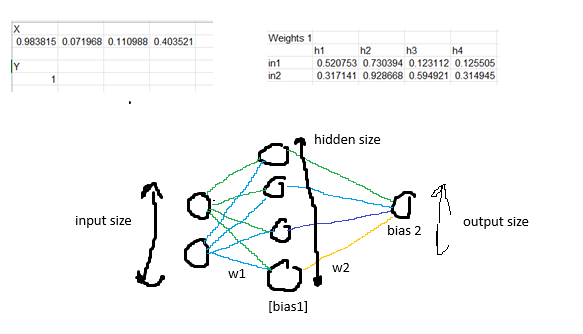
 Where X and Y reffer to a given Index of the data and label arrays X and Y

In [8]:
class MLP:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        
        # initialize weights randomly
        self.weights1 = np.random.randn(self.input_size, self.hidden_size)
        self.weights2 = np.random.randn(self.hidden_size, self.output_size)
        print("The Inital Shape of the MLP is:  \n  Weights1: \n" )
        print(self.weights1)
        print("\n Weights2: \n" )
        print(self.weights2)
            
        # initialize biases to 0
        self.bias1 = np.zeros((1, self.hidden_size))
        self.bias2 = np.zeros((1, self.output_size))
    
    ### Training the Neural network ~~~~~~~~~~~~~~
    def fit(self, X, y, epochs=1000):
        for epoch in range(epochs):
            # feedforward
            layer1 = X.dot(self.weights1) + self.bias1
            activation1 = sigmoid(layer1)
            layer2 = activation1.dot(self.weights2) + self.bias2
            activation2 = sigmoid(layer2)
            
            # backpropagation
            error = activation2 - y
            d_weights2 = activation1.T.dot(error * sigmoid_derivative(layer2))
            d_bias2 = np.sum(error * sigmoid_derivative(layer2), axis=0, keepdims=True)
            error_hidden = error.dot(self.weights2.T) * sigmoid_derivative(layer1)
            d_weights1 = X.T.dot(error_hidden)
            d_bias1 = np.sum(error_hidden, axis=0, keepdims=True)
            
            # update weights and biases
            self.weights2 -= self.learning_rate * d_weights2
            self.bias2 -= self.learning_rate * d_bias2
            self.weights1 -= self.learning_rate * d_weights1
            self.bias1 -= self.learning_rate * d_bias1
    

    def predict(self, X):
        layer1 = X.dot(self.weights1) + self.bias1
        activation1 = sigmoid(layer1)
        layer2 = activation1.dot(self.weights2) + self.bias2
        activation2 = sigmoid(layer2)
        return (activation2 > 0.5).astype(int)



$$Layer = (X\cdot weights) + bias $$


# Refrences 
- https://abtinmy.github.io/CS-SBU-NeuralNetwork/lectures/introduction/MLP-Scratch-Iris  Github repo for the associated course

https://github.com/Abtinmy/CS-SBU-NeuralNetwork Overivew of the project. 